# **Libraries**

In [1]:
!pip install scikit-learn pandas numpy openpyxl matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

# **Train**

In [3]:
label2id = {"negatif": 0, "netral": 1, "positif": 2}
id2label = {0: "negatif", 1: "netral", 2: "positif"}
RANDOM_STATE = 42

In [4]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform the text data after splitting in the next steps
print("TF-IDF Vectorizer initialized.")

TF-IDF Vectorizer initialized.


In [5]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Updated path to your specific preprocessed dataset
file_path = '/content/drive/MyDrive/Thesis/final_preprocessed.xlsx'

# Load the dataset
df = pd.read_excel(file_path)

# 1. Basic Cleaning: Drop rows where clean_text or sentiment is missing
df = df.dropna(subset=['clean_text', 'sentiment'])

# 2. Standardize labels (remove whitespace and lowercase) to ensure mapping works
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()

# 3. Map labels to IDs
df['sentiment'] = df['sentiment'].map(label2id)

# 4. Final check: Drop any rows where mapping failed (if any unexpected labels existed)
df = df.dropna(subset=['sentiment'])
df['sentiment'] = df['sentiment'].astype(int)

print(f"Dataset loaded and cleaned. Final count: {len(df)} samples.")
display(df.head())
print("Label distribution:")
print(df['sentiment'].value_counts())

Mounted at /content/drive
Dataset loaded and cleaned. Final count: 6028 samples.


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,source,keyword,clean_text,sentiment
0,6a7dbd15-2507-4f2c-bd2c-d36bbc89c640,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,masa Bank BUMN terbesar rating nya 4.1..tadiny...,3,0,NaN,2025-12-15 13:26:18+00:00,"Hai Sahabat @Alexander Luberizky, mohon maaf a...",2025-12-15 13:29:19,NaN,Dataset/dataset\LIVIN_googleplay_DECEMBER_revi...,qris,bank bumn terbesar rating nya ga komplainliat ...,0
1,c7f1469f-42f5-4dad-86eb-13aca28e5cf7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa tidak bisa masuk ke aplikasi livin kami...,2,0,3.1.0,2025-11-04 10:11:46+00:00,"Halo Sahabat @Salma Laudengi, mohon maaf atas ...",2025-11-04 10:33:49,3.1.0,Dataset/dataset\LIVIN_googleplay_NOVEMBER_revi...,login,tidak masuk aplikasi livin peningkatan layanan...,1
2,3bde987d-6726-4ed8-8cc7-de39a3331f68,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"heran aku, kejadian bukan 1 kali jadi di ATM s...",3,0,1.60.0,2025-10-22 21:59:11+00:00,NaN,NaN,1.60.0,Dataset/dataset\GOPAY_googleplay_OCTOBER_revie...,transfer,heran kejadian bukan kali atm saldo bri k tf j...,0
3,91616e30-ada7-4242-8872-ab3e310881f2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Apk nya bagus cmn kebykn nyangkut di e-toll ud...,1,4,1.59.0,2025-10-04 16:41:42+00:00,"Hai Kak Widia, mohon maaf atas ketidaknyamanan...",2025-10-04 18:53:40,1.59.0,Dataset/dataset\GOPAY_googleplay_OCTOBER_revie...,topup,apk nya bagus cmn kebykn nyangkut etoll udh to...,0
4,beffc9f7-fa71-4ab9-9fe8-17c66bab72b0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,knp kalo mau transfer harus upgrade ke gopay p...,4,0,1.64.1,2025-11-26 07:54:47+00:00,NaN,NaN,1.64.1,Dataset/dataset\GOPAY_googleplay_NOVEMBER_revi...,transfer,knp kalo transfer upgrade gopay plus dlu,1


Label distribution:
sentiment
0    4472
2     906
1     650
Name: count, dtype: int64


In [6]:
X = df['clean_text']
y = df['sentiment']
# step 1 — 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
# step 2 — 50% of temp = 10% total test, rest = 10% val
X_val, X_test, y_val, y_test = train_test_split(
X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)
print(f"Train : {len(X_train)} samples")
print(f"Val : {len(X_val)} samples")
print(f"Test : {len(X_test)} samples")


Train : 4822 samples
Val : 603 samples
Test : 603 samples


In [7]:
# Transform text to TF-IDF features
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF transformation complete.")
print(f"Train shape: {X_train_tfidf.shape}")

TF-IDF transformation complete.
Train shape: (4822, 5000)


## **Stage 1: Baseline Model (Initial Performance)**
We train a standard Multinomial Naive Bayes model without any adjustments to establish a baseline. This helps us visualize the impact of class imbalance before we apply improvements.


==================== Baseline NB (Validation) ====================
              precision    recall  f1-score   support

     negatif       0.79      1.00      0.88       447
      netral       0.00      0.00      0.00        65
     positif       0.94      0.37      0.54        91

    accuracy                           0.80       603
   macro avg       0.58      0.46      0.47       603
weighted avg       0.73      0.80      0.73       603

Weighted ROC AUC Score: 0.8807


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


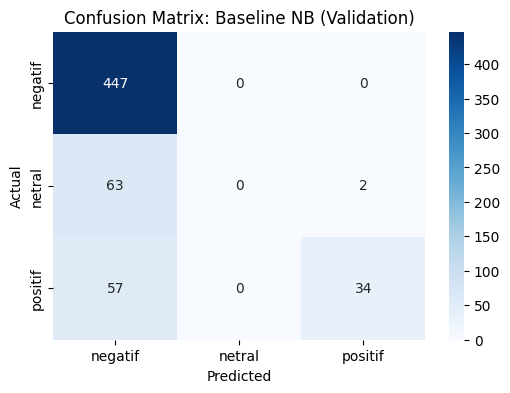

In [8]:
def plot_evaluation(y_true, y_pred, y_prob, title):
    # 1. Print Text Metrics
    print(f"\n{'='*20} {title} {'='*20}")
    print(classification_report(y_true, y_pred, target_names=list(label2id.keys())))

    # 2. Calculate ROC AUC
    roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted')
    print(f"Weighted ROC AUC Score: {roc_auc:.4f}")

    # 3. Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label2id.keys(), yticklabels=label2id.keys())
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# --- STAGE 1: BASELINE ---
nb_baseline = MultinomialNB()
nb_baseline.fit(X_train_tfidf, y_train)

y_pred_base = nb_baseline.predict(X_val_tfidf)
y_prob_base = nb_baseline.predict_proba(X_val_tfidf)
plot_evaluation(y_val, y_pred_base, y_prob_base, "Baseline NB (Validation)")

### **Improvement: Resampling and Hyperparameter Tuning**

Since the dataset is highly imbalanced (mostly 'negatif'), we use `RandomOverSampler` to balance the training set. We then use `GridSearchCV` to find the best `alpha` for the `MultinomialNB` model.

Best Alpha from SMOTE tuning: 0.01

==================== SMOTE-Tuned & Weighted-Train NB ====================
              precision    recall  f1-score   support

     negatif       0.84      0.98      0.91       447
      netral       0.54      0.11      0.18        65
     positif       0.86      0.65      0.74        91

    accuracy                           0.84       603
   macro avg       0.75      0.58      0.61       603
weighted avg       0.81      0.84      0.80       603

Weighted ROC AUC Score: 0.8854


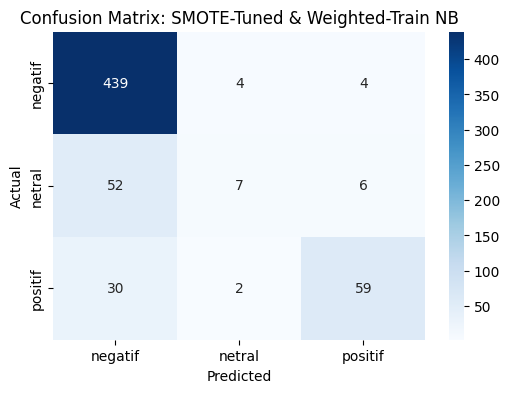

In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
import numpy as np

# 1. SMOTE for Hyperparameter Tuning
# We use SMOTE here to find the best alpha on a balanced representation
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)

param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}
nb_grid = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='f1_weighted')
nb_grid.fit(X_train_res, y_train_res)

best_alpha = nb_grid.best_params_['alpha']
print(f"Best Alpha from SMOTE tuning: {best_alpha}")

# 2. Class Imbalance Handling for Training (Weighted Trainer)
# Calculate priors based on the original imbalanced distribution
counts = np.bincount(y_train)
priors = counts / len(y_train)

# Train final model using the best alpha AND the class priors (weights)
best_nb_model = MultinomialNB(alpha=best_alpha, class_prior=priors)
best_nb_model.fit(X_train_tfidf, y_train)

# 3. Validation
y_pred_tuned = best_nb_model.predict(X_val_tfidf)
y_prob_tuned = best_nb_model.predict_proba(X_val_tfidf)
plot_evaluation(y_val, y_pred_tuned, y_prob_tuned, "SMOTE-Tuned & Weighted-Train NB")

### **Evaluate Weighted Model**


==================== Final Optimized NB (Test Data) ====================
              precision    recall  f1-score   support

     negatif       0.86      0.99      0.92       448
      netral       0.55      0.09      0.16        65
     positif       0.91      0.77      0.83        90

    accuracy                           0.86       603
   macro avg       0.77      0.62      0.64       603
weighted avg       0.83      0.86      0.82       603

Weighted ROC AUC Score: 0.8986


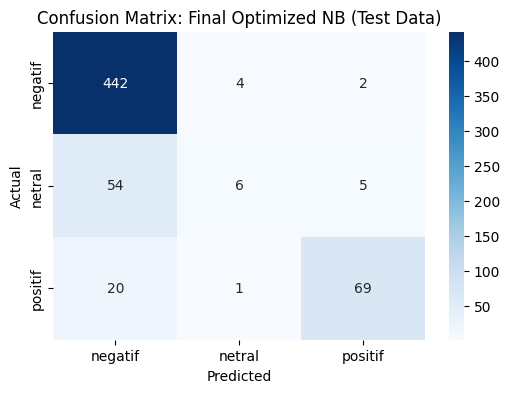

Final results saved to Google Drive.


In [10]:
import os

y_pred_test = best_nb_model.predict(X_test_tfidf)
y_prob_test = best_nb_model.predict_proba(X_test_tfidf)

# Final Report
plot_evaluation(y_test, y_pred_test, y_prob_test, "Final Optimized NB (Test Data)")

# Save Results for Thesis Analysis
test_results_df = pd.DataFrame({
    'text': X_test.tolist(),
    'true_label': [id2label[i] for i in y_test],
    'predicted_label': [id2label[i] for i in y_pred_test]
})

os.makedirs('/content/drive/MyDrive/Thesis/results', exist_ok=True)
test_results_df.to_csv('/content/drive/MyDrive/Thesis/results/final_NB_results.csv', index=False)
print("Final results saved to Google Drive.")

### **Class Distribution Analysis**

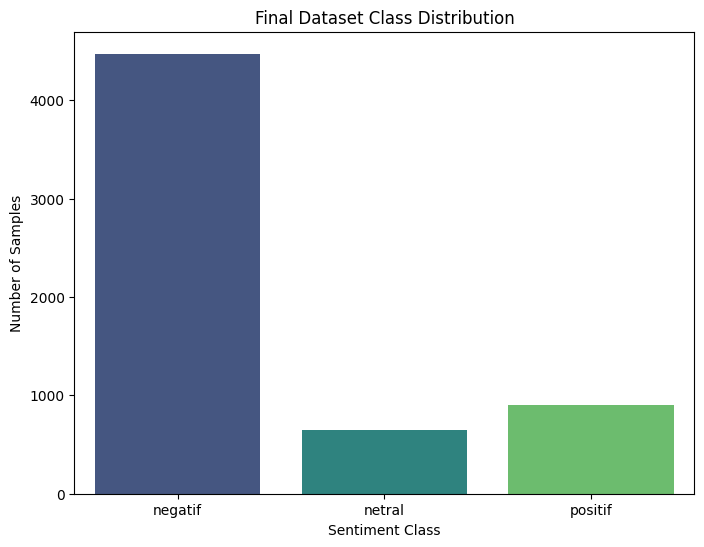

In [11]:
# The class distribution visualization remains here for your data analysis section.
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = df['sentiment'].value_counts().sort_index()
labels = [id2label[i] for i in label_counts.index]

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=label_counts.values, palette='viridis', hue=labels, legend=False)
plt.title('Final Dataset Class Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Samples')
plt.show()

In [12]:
# import numpy as np
# from sklearn.preprocessing import label_binarize
# from sklearn.metrics import roc_curve, auc
# import os
# import matplotlib.pyplot as plt

# # --- Configuration for NB ROC data ---
# # Consistent with variables: best_nb_model, X_test_tfidf, y_test
# ROC_MODEL_NAME = "NB-Lexnorm"
# ROC_SAVE_DIR = "/content/drive/MyDrive/Thesis/results/roc_data"
# NUM_CLASSES = 3

# # Re-verifying label mappings from previous cells
# id2label = {0: "negatif", 1: "netral", 2: "positif"}
# label2id = {"negatif": 0, "netral": 1, "positif": 2}

# def save_macro_roc_data(y_true, y_score, model_name, num_classes, save_dir="roc_data"):
#     """
#     Calculates macro-averaged ROC curve data and saves it as NB_Default.npz.
#     """
#     os.makedirs(save_dir, exist_ok=True)

#     y_true = np.asarray(y_true)
#     y_score = np.asarray(y_score)

#     # Binarize labels for multi-class ROC (One-vs-Rest)
#     y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

#     # Handle binary case edge case if necessary
#     if num_classes == 2 and y_true_bin.shape[1] == 1:
#         y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])

#     # Compute ROC for each class
#     fpr_dict, tpr_dict = {}, {}
#     for i in range(num_classes):
#         fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])

#     # --- Macro-averaging logic ---
#     all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(num_classes)]))
#     mean_tpr = np.zeros_like(all_fpr)
#     for i in range(num_classes):
#         mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
#     mean_tpr /= num_classes

#     macro_auc = auc(all_fpr, mean_tpr)

#     # Save data for the final comparison notebook/section
#     out_path = os.path.join(save_dir, "NB_Norm.npz")
#     np.savez(out_path, fpr=all_fpr, tpr=mean_tpr, auc=macro_auc)
#     print(f"Results for {model_name} saved. Macro AUC: {macro_auc:.4f}")

#     return all_fpr, mean_tpr, macro_auc

# # --- Implementation for Naive Bayes ---
# # Using the optimized model 'best_nb_model' and the test sets defined earlier
# y_score = best_nb_model.predict_proba(X_test_tfidf)

# # Generate and save ROC results
# nb_fpr, nb_tpr, nb_auc = save_macro_roc_data(
#     y_test,
#     y_score,
#     model_name=ROC_MODEL_NAME,
#     num_classes=NUM_CLASSES,
#     save_dir=ROC_SAVE_DIR
# )

# # --- Visualization ---
# plt.figure(figsize=(8, 6))
# plt.plot(nb_fpr, nb_tpr, color='darkorange', lw=2, label=f'{ROC_MODEL_NAME} (AUC = {nb_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title(f'ROC Curve: {ROC_MODEL_NAME}')
# plt.legend(loc="lower right")
# plt.grid(True, linestyle=':', alpha=0.7)
# plt.show()

Saved PR Data for NB-Reg: macro-average PR-AUC = 0.7161 to /content/drive/MyDrive/Thesis/results/pr_data/NB_Reg_PR.npz


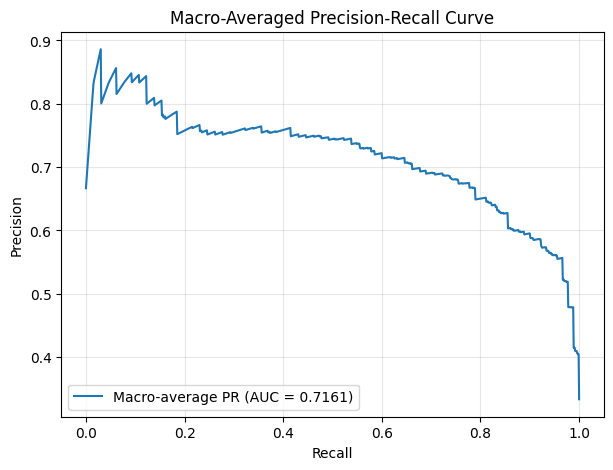

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc

def save_macro_pr_data(y_true, y_score, model_name, num_classes, save_dir="/content/drive/MyDrive/Thesis/results/pr_data"):
    """
    Calculates macro-averaged Precision-Recall data and saves to .npz.
    """
    os.makedirs(save_dir, exist_ok=True)

    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    if num_classes == 2:
        y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])

    # Precision and recall for each class
    precision_dict = {}
    recall_dict = {}

    # Use a common grid for interpolation (Recall from 0 to 1)
    mean_recall = np.linspace(0, 1, 1000)
    mean_precision = np.zeros_like(mean_recall)

    for i in range(num_classes):
        precision_dict[i], recall_dict[i], _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
        # Interpolate precision to the common recall grid
        # We flip them because precision_recall_curve returns recall in descending order
        mean_precision += np.interp(mean_recall, recall_dict[i][::-1], precision_dict[i][::-1])

    mean_precision /= num_classes
    macro_pr_auc = auc(mean_recall, mean_precision)

    out_path = os.path.join(save_dir, f"NB_Reg_PR.npz")
    np.savez(out_path, recall=mean_recall, precision=mean_precision, auc=macro_pr_auc)

    print(f"Saved PR Data for {model_name}: macro-average PR-AUC = {macro_pr_auc:.4f} to {out_path}")

    return mean_recall, mean_precision, macro_pr_auc

# --- Fixed Call using existing notebook variables ---
# ROC_MODEL_NAME and NUM_CLASSES are used as defined in previous cells
recall_grid, precision_grid, pr_auc = save_macro_pr_data(
    y_true=y_test,
    y_score=y_prob_test,
    model_name="NB-Reg",
    num_classes=3,
    save_dir="/content/drive/MyDrive/Thesis/results/pr_data"
)

# Quick Plot visualization
plt.figure(figsize=(7, 5))
plt.plot(recall_grid, precision_grid, label=f'Macro-average PR (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-Averaged Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()